# 06 — Evaluation and Findings

## Purpose

Final evaluation of the tuned XGBoost model on the held-out test period
(2020–2024). We produce:

1. A complete model comparison table (including naive baselines).
2. XGBoost feature importance.
3. MAE by GDP-per-capita group.
4. MAE by country.
5. Actual vs predicted diagnostics.
6. Overfitting analysis (train vs test gaps).

## Model under evaluation

The final model is the **tuned XGBoost** identified by Grid Search in
`05_hyperparameter_tuning.ipynb`:

| Parameter | Value |
|---|---|
| colsample_bytree | 0.70 |
| learning_rate | 0.035 |
| max_depth | 6 |
| n_estimators | 90 |
| reg_lambda | 1.0 |
| subsample | 0.85 |

The test set was not used to select this model — only to report its performance here.

The model is rebuilt from scratch in this notebook using `make_final_model()`,
so the reader can verify the exact configuration without needing to re-run
notebook 05.

In [13]:
import sys
from pathlib import Path

current = Path.cwd()
project_root = current.parent if current.name == "notebooks" else current
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

from src import config, split, models, evaluate, plots

In [15]:
df = pd.read_csv(config.MODEL_DATA_PATH)
df = df.sort_values([config.YEAR_COL, config.COUNTRY_CODE_COL]).reset_index(drop=True)
X_train, y_train, X_test, y_test = split.get_train_test(df)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (675, 11)  Test: (135, 11)


In [16]:
FINAL_PARAMS = dict(
    colsample_bytree=0.7,
    learning_rate=0.035,
    max_depth=6,
    n_estimators=90,
    reg_lambda=1.0,
    subsample=0.85,
)

def make_final_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   XGBRegressor(
            **FINAL_PARAMS,
            random_state=config.RANDOM_STATE,
            n_jobs=-1, verbosity=0,
        )),
    ])

final_model = make_final_model()
final_model.fit(X_train, y_train)
print("Final model fitted.")

Final model fitted.


## 1. Final model comparison

All five models (plus the two naive baselines) are evaluated on the same
chronological test period (2020–2024). Primary metric: **test MAE**
(average absolute error in GDP-growth percentage points).

A model can only be considered useful if it beats the naive mean baseline.

In [17]:
from src.models import (
    build_mean_baseline, build_persistence_baseline,
    build_linear_regression, build_random_forest,
)

candidates = [
    ("Naive: mean",              build_mean_baseline()),
    ("Naive: persistence",       build_persistence_baseline()),
    ("Linear Regression",        build_linear_regression()),
    ("Random Forest",            build_random_forest()),
    ("XGBoost baseline",         models.build_xgboost_baseline()),
    ("XGBoost GridSearch tuned", make_final_model()),
]

final_table = evaluate.build_comparison_table(
    candidates, X_train, y_train, X_test, y_test
)
final_table = final_table.sort_values("test_MAE")
print(final_table)
final_table.to_csv(config.PROCESSED_DIR / "final_comparison.csv")

                          train_MAE  test_MAE  train_RMSE  test_RMSE  \
model                                                                  
Naive: mean                   2.599     2.490       3.819      3.401   
Linear Regression             2.243     2.748       3.415      4.259   
XGBoost GridSearch tuned      1.148     2.841       1.629      3.830   
Random Forest                 0.962     3.131       1.656      4.095   
XGBoost baseline              0.785     3.503       1.089      4.451   
Naive: persistence            2.558     4.214       4.068      6.234   

                          train_R2  test_R2  
model                                        
Naive: mean                  0.000   -0.050  
Linear Regression            0.200   -0.647  
XGBoost GridSearch tuned     0.818   -0.332  
Random Forest                0.812   -0.523  
XGBoost baseline             0.919   -0.799  
Naive: persistence          -0.135   -2.529  


### Interpretation

The complete ranking on test MAE:

| Rank | Model | Test MAE | Test R² |
|---|---|---|---|
| 1 | **Naive: mean** | **2.490** | −0.050 |
| 2 | Linear Regression | 2.748 | −0.647 |
| 3 | XGBoost GridSearch tuned | 2.841 | **−0.332** |
| 4 | Random Forest | 3.131 | −0.523 |
| 5 | XGBoost baseline | 3.503 | −0.799 |
| 6 | Naive: persistence | 4.214 | −2.529 |

**Key observations:**

1. **The naive mean baseline wins on test MAE.** No ML model beats it.
   This is the central, honest finding of the project.

2. **Tuning helped substantially.** The tuned XGBoost reduces test MAE
   from 3.50 (baseline) to 2.84 — a 19% improvement.

3. **Linear Regression beats the tuned XGBoost on MAE** (2.75 vs 2.84)
   but loses on R² (−0.65 vs −0.33). **Hypothesis 1** ("XGBoost will
   achieve better predictive performance than the Linear Regression
   baseline") is **not supported** under the primary metric MAE.

4. **Tuned XGBoost beats Random Forest** on both MAE (2.84 vs 3.13) and
   R² (−0.33 vs −0.52). **Hypothesis 2 supported** for the tuned model.

5. **Persistence is by far the worst model** (test R² = −2.53). This
   confirms mean reversion in GDP growth: extreme years tend to revert,
   so copying last year's value overshoots.

Note on the naive mean's test R². The naive mean predicts the training mean (2.60) for every test row. Its test R² is slightly negative (−0.05) because the test-period mean (2.49) differs from the training-period mean. This is expected — a truly "zero-information" predictor has R² = 0 only when train and test means coincide.

### Visual comparison of test MAE by model

The table above gives exact numbers; this chart makes the ranking
immediate. Each bar shows test MAE for one model, sorted so the best
model is at the top.

The **green bar** is the naive mean baseline — the benchmark that no ML
model beats. The **orange bar** is the tuned XGBoost, the project's
flagship model. The red dashed line marks the naive mean's MAE, so you
can immediately see which models are above it (none) and which are below.

The chart is saved to `data/processed/test_mae_by_model.png` for use in
the presentation slides.

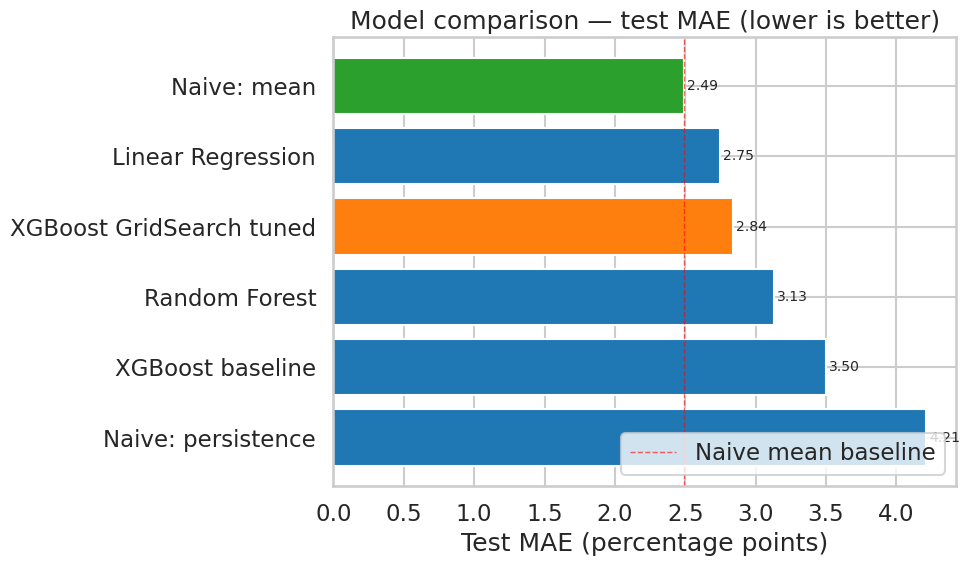

In [18]:
# --- Bar chart: test MAE by model ---
# Horizontal, sorted ascending (best model at top).
# Naive mean is highlighted in green to make the "winner" obvious.

# Sort so the best (lowest MAE) appears at the top
plot_df = final_table.sort_values("test_MAE", ascending=True)

# Colour code: green for the naive mean (the winner), orange for the
# tuned XGBoost, steel blue for everything else
def bar_colour(name):
    if "Naive: mean" in name:
        return "#2ca02c"  # green
    if "GridSearch" in name:
        return "#ff7f0e"  # orange
    return "#1f77b4"      # steel blue

colours = [bar_colour(name) for name in plot_df.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df.index, plot_df["test_MAE"], color=colours)
ax.set_xlabel("Test MAE (percentage points)")
ax.set_title("Model comparison — test MAE (lower is better)")
ax.invert_yaxis()  # so the best model appears at the top

# Add value labels at the end of each bar
for i, (name, row) in enumerate(plot_df.iterrows()):
    ax.text(row["test_MAE"] + 0.02, i, f"{row['test_MAE']:.2f}",
            va="center", fontsize=10)

# Reference line at the naive mean's MAE
ax.axvline(plot_df.loc["Naive: mean", "test_MAE"], 
           color="red", linestyle="--", linewidth=1, alpha=0.6,
           label="Naive mean baseline")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(config.PROCESSED_DIR / "test_mae_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

                           feature  importance
                        gdp_growth    0.148818
                         inflation    0.105967
government_consumption_percent_gdp    0.102431
                  gdp_growth_lag_1    0.095470
                      unemployment    0.086483
                    gdp_per_capita    0.082122
     gross_fixed_capital_formation    0.081896
                 population_growth    0.079548
                    trade_openness    0.074860
                  gdp_growth_lag_2    0.074617
           fdi_inflows_percent_gdp    0.067789


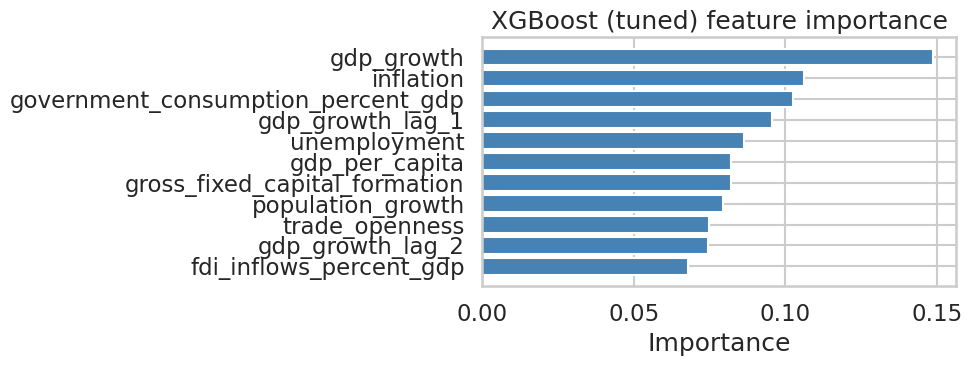

In [19]:
# Extract the XGBoost step from the pipeline and get importances
xgb_model = final_model.named_steps["model"]
importance_df = pd.DataFrame({
    "feature":    split.FEATURE_COLS,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))
importance_df.to_csv(config.PROCESSED_DIR / "feature_importance.csv", index=False)

fig, ax = plots.plot_feature_importance(
    importance_df,
    top_n=11,
    title="XGBoost (tuned) feature importance"
)
plt.show()

### Interpretation

Feature importances in the tuned XGBoost:

| Rank | Feature | Importance |
|---|---|---|
| 1 | gdp_growth | 0.149 |
| 2 | inflation | 0.106 |
| 3 | government_consumption_percent_gdp | 0.102 |
| 4 | gdp_growth_lag_1 | 0.095 |
| 5 | unemployment | 0.086 |
| 6 | gdp_per_capita | 0.082 |
| 7 | gross_fixed_capital_formation | 0.082 |
| 8 | population_growth | 0.080 |
| 9 | trade_openness | 0.075 |
| 10 | gdp_growth_lag_2 | 0.075 |
| 11 | fdi_inflows_percent_gdp | 0.068 |

**Observations:**

1. **The importance distribution is remarkably flat** — the strongest
   feature (`gdp_growth`, 0.149) is only ~2.2× the weakest
   (`fdi_inflows_percent_gdp`, 0.068). No single feature dominates.

2. **Previous GDP growth is #1**, matching economic intuition and
   **Hypothesis 4**. Inflation ranks #2.

3. However, **investment (`gross_fixed_capital_formation`, #7) and
   trade (`trade_openness`, #9)** are less important than hypothesised.
   **Hypothesis 4 is partially supported.**

4. **The flatness itself is a finding**: XGBoost does not find a strong
   signal in any individual feature, consistent with the model's weak
   overall predictive performance.

**Reminder**: feature importance reflects *predictive usefulness in this
model*, not causality. A high-importance feature is not a cause of GDP
growth.

In [20]:
# Predictions on the test set
test_pred = final_model.predict(X_test)

# Pull metadata for test rows so we can group/analyse
test_meta = df[df[config.SPLIT_COL] == "test"].copy()
test_meta = test_meta.sort_values([config.YEAR_COL, config.COUNTRY_CODE_COL]).reset_index(drop=True)
test_meta["prediction"] = test_pred
test_meta["error"] = test_meta[config.TARGET_COL] - test_meta["prediction"]
test_meta["abs_error"] = test_meta["error"].abs()

print(test_meta[[config.COUNTRY_CODE_COL, config.YEAR_COL,
                 config.TARGET_COL, "prediction", "error", "abs_error"]].head(10))

  Country Code  Year  target_gdp_growth_next_year  prediction     error  \
0          AUT  2020                     4.923092    0.719455  4.203637   
1          BEL  2020                     6.254457    1.500116  4.754341   
2          BGR  2020                     7.828173    1.921048  5.907125   
3          CYP  2020                    11.397559    2.864657  8.532902   
4          CZE  2020                     4.029018   -2.011477  6.040495   
5          DEU  2020                     3.910000    2.131634  1.778366   
6          DNK  2020                     6.500254    2.022020  4.478234   
7          ESP  2020                     6.683144    0.679007  6.004137   
8          EST  2020                     8.254880    2.194233  6.060647   
9          FIN  2020                     2.676346    1.407185  1.269161   

   abs_error  
0   4.203637  
1   4.754341  
2   5.907125  
3   8.532902  
4   6.040495  
5   1.778366  
6   4.478234  
7   6.004137  
8   6.060647  
9   1.269161  


### Saving test-set predictions for downstream use

The `test_meta` DataFrame now contains, for every test-period
country-year observation:

- **Identifiers**: `Country Code`, `Year`
- **Ground truth**: `target_gdp_growth_next_year`
- **Prediction**: `prediction` (from the tuned XGBoost)
- **Error metrics**: `error` (signed), `abs_error` (absolute)
- **Group labels**: `gdp_per_capita_group` (Lower / Middle / Higher)

We save this to `test_predictions.csv` so that notebook 07/08 and the
slide build can reference the exact predictions without re-running
notebook 06.

In [21]:
# --- Save predictions with metadata for downstream use ---
# test_meta contains: Country, Year, target, prediction, error, abs_error
# plus gdp_per_capita_group and dataset_split.
# Saved so notebooks 07/08 and the slide build can reference it directly
# without re-running notebook 06.

predictions_path = config.PROCESSED_DIR / "test_predictions.csv"
test_meta.to_csv(predictions_path, index=False)
print(f"Saved {len(test_meta)} test predictions to:")
print(predictions_path)

# Quick sanity check
print()
print("Preview of saved predictions:")
print(test_meta[[
    config.COUNTRY_CODE_COL,
    config.YEAR_COL,
    config.TARGET_COL,
    "prediction",
    "abs_error",
]].head().round(3))

Saved 135 test predictions to:
/home/ricci-preto/IronHack/Classes/ML Project/data/processed/test_predictions.csv

Preview of saved predictions:
  Country Code  Year  target_gdp_growth_next_year  prediction  abs_error
0          AUT  2020                        4.923       0.719      4.204
1          BEL  2020                        6.254       1.500      4.754
2          BGR  2020                        7.828       1.921      5.907
3          CYP  2020                       11.398       2.865      8.533
4          CZE  2020                        4.029      -2.011      6.040


### Saving full-dataset predictions (train + test)

The test-set predictions above are what we use for headline evaluation.
For certain visualisations — particularly a time-series view of
predicted vs actual GDP growth by year — it's useful to have predictions
for the **entire dataset** (both train and test periods).

This cell runs the final model on all 810 rows and saves:

- **Identifiers**: `Country Code`, `Country Name`, `Year`
- **Split label**: `dataset_split` (`train` / `test`)
- **Group label**: `gdp_per_capita_group`
- **Ground truth**: `target_gdp_growth_next_year`
- **Prediction**: `prediction`
- **Errors**: `error`, `abs_error`

Note that train-period predictions are **in-sample** — the model has
already seen these rows during fitting. They are useful for diagnosing
overfitting (comparing in-sample vs out-of-sample fit) but must **not**
be used for performance reporting.

In [22]:
# --- Save predictions for the full dataset ---
# Some slides benefit from seeing train-period and test-period predictions
# on the same plot. This saves predictions for all 810 rows.

df_full = df.copy()
df_full["prediction"] = final_model.predict(df_full[split.FEATURE_COLS])
df_full["error"] = df_full[config.TARGET_COL] - df_full["prediction"]
df_full["abs_error"] = df_full["error"].abs()

full_path = config.PROCESSED_DIR / "all_predictions.csv"
df_full[[
    config.COUNTRY_CODE_COL, config.COUNTRY_NAME_COL, config.YEAR_COL,
    config.SPLIT_COL, config.GROUP_COL,
    config.TARGET_COL, "prediction", "error", "abs_error"
]].to_csv(full_path, index=False)
print(f"Saved {len(df_full)} predictions to:")
print(full_path)

Saved 810 predictions to:
/home/ricci-preto/IronHack/Classes/ML Project/data/processed/all_predictions.csv


MAE by GDP-per-capita group:
gdp_per_capita_group
Higher GDP per capita    2.704
Lower GDP per capita     2.816
Middle GDP per capita    3.003
Name: abs_error, dtype: float64


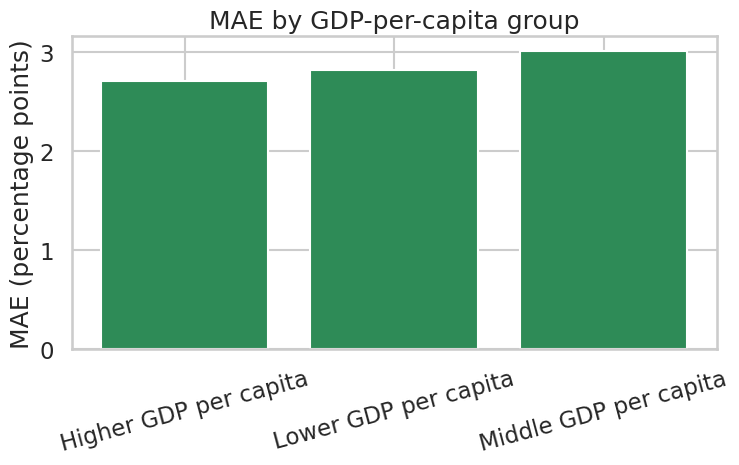

In [23]:
group_mae = test_meta.groupby(config.GROUP_COL)["abs_error"].mean().sort_values()
print("MAE by GDP-per-capita group:")
print(group_mae.round(3))

fig, ax = plots.plot_group_mae(group_mae)
plt.show()
group_mae.to_csv(config.PROCESSED_DIR / "group_mae.csv")

### Interpretation

MAE by GDP-per-capita group (tertiles of 9 countries each):

| Group | MAE |
|---|---|
| Higher GDP per capita | 2.704 |
| Lower GDP per capita | 2.816 |
| Middle GDP per capita | 3.003 |

**Observations:**

1. **The differences are small** — a range of 0.30 percentage points
   (about 11%) across groups. The model performs roughly similarly
   regardless of income level.

2. **The relationship is not monotonic.** Richer countries are *mildly*
   the easiest to predict, but the **Middle** group is the hardest —
   harder even than the Lower group.

3. **Hypothesis 5** ("Predictive accuracy will differ across EU economies
   with different GDP-per-capita levels") is **weakly supported**:
   accuracy does vary, but the differences are small and the pattern is
   not the simple "rich easier, poor harder" one might expect.

**Important caveat**: with 9 countries per group and 5 test years, each
group MAE is estimated from just 45 observations. Small differences
should be interpreted as suggestive, not definitive. The next section
shows that country-level differences are much larger than group-level
differences — suggesting group MAEs are driven by individual countries
within each group.

MAE by country (top 10 highest error):
Country Code
SVN    3.123
CZE    3.204
EST    3.221
DNK    3.398
HUN    3.424
CYP    3.576
POL    3.846
HRV    4.689
MLT    5.479
IRL    6.737
Name: abs_error, dtype: float64

MAE by country (top 10 lowest error):
Country Code
FIN    1.323
DEU    1.334
LTU    1.454
ROU    1.651
BEL    1.785
PRT    1.885
SWE    1.909
LVA    2.054
FRA    2.060
BGR    2.099
Name: abs_error, dtype: float64


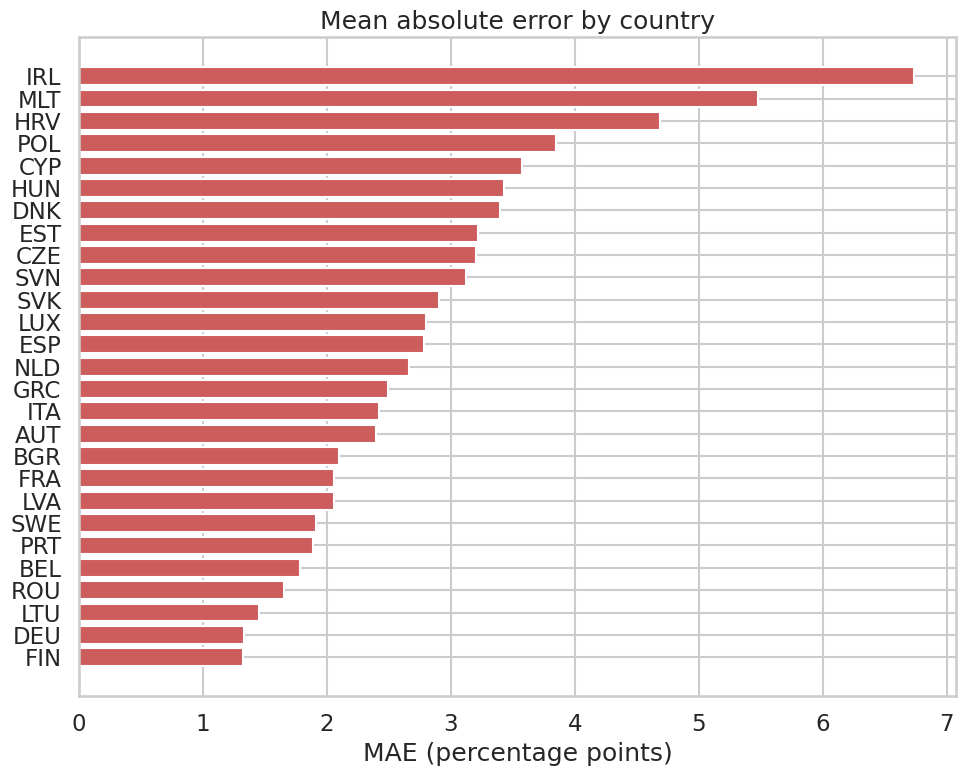

In [24]:
country_mae = test_meta.groupby(config.COUNTRY_CODE_COL)["abs_error"].mean().sort_values()
print("MAE by country (top 10 highest error):")
print(country_mae.tail(10).round(3))
print()
print("MAE by country (top 10 lowest error):")
print(country_mae.head(10).round(3))

fig, ax = plots.plot_country_mae(country_mae)
plt.show()
country_mae.to_csv(config.PROCESSED_DIR / "country_mae.csv")

### Interpretation

**Hardest countries to predict (test MAE):**

| Country | MAE |
|---|---|
| Ireland (IRL) | 6.74 |
| Malta (MLT) | 5.48 |
| Croatia (HRV) | 4.69 |
| Poland (POL) | 3.85 |
| Cyprus (CYP) | 3.58 |

**Easiest countries to predict (test MAE):**

| Country | MAE |
|---|---|
| Finland (FIN) | 1.32 |
| Germany (DEU) | 1.33 |
| Lithuania (LTU) | 1.45 |
| Romania (ROU) | 1.65 |
| Belgium (BEL) | 1.79 |

**Observations:**

1. **Country-level differences are far larger than group-level
   differences.** Test MAE ranges from 1.3 (Finland) to 6.7 (Ireland)
   — a factor of ~5×. Group-level differences were only ~1.1×.

2. **This suggests the group analysis is largely driven by individual
   countries.** Ireland's extreme MAE, for example, single-handedly
   inflates the Middle group's average.

3. **Ireland's poor performance is expected and explainable:**
   - Ireland's 2015 growth rate (+25%) was driven by a single
     multinational accounting event, not real economic activity.
   - Ireland's post-COVID 2021 growth (+13.5%) was similarly
     multinational-driven and unpredictable from macro indicators.

4. **Malta, Croatia, and Cyprus** are small, open, service-heavy
   economies whose growth is dominated by idiosyncratic shocks.

5. **This answers Research Question 9:** differences between
   GDP-per-capita groups are **not** a broad economic pattern — they
   are driven by a small number of unusual countries within each group.

**Takeaway**: predictive difficulty is a country-level property, not a
development-level one. Structural characteristics of individual
economies matter more than their income tier.

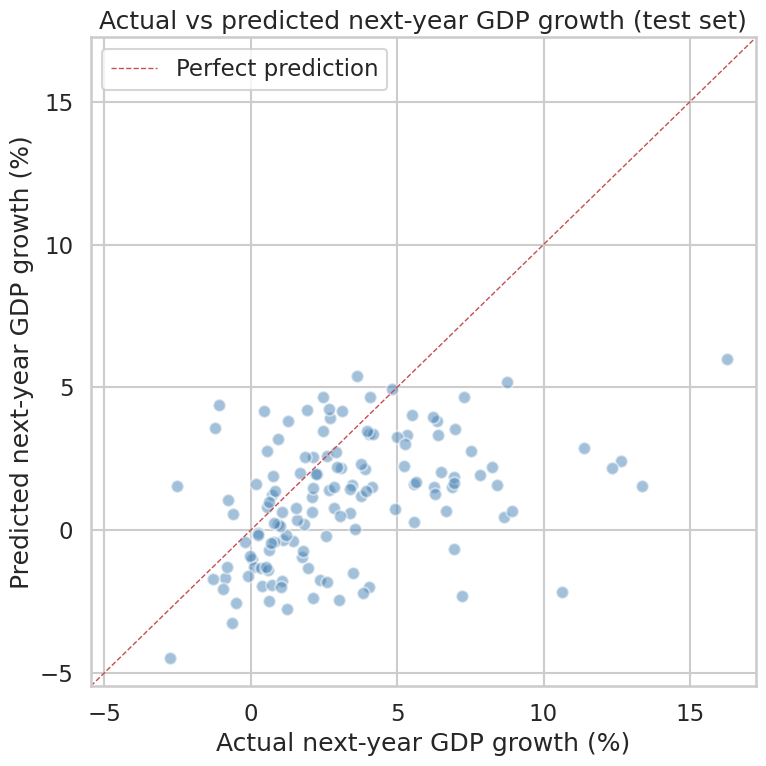

In [25]:
fig, ax = plots.plot_actual_vs_predicted(
    test_meta[config.TARGET_COL],
    test_meta["prediction"],
    title="Actual vs predicted next-year GDP growth (test set)"
)
plt.show()

### Interpretation

The scatter is **flat**: predicted values cluster in the range 0–3%,
while actual next-year growth ranges from −5% to +17%. Very few points
lie near the diagonal, and the visual cloud does not follow it.

This is the direct visual counterpart of the negative test R²:
the model explains less variance in the test target than a constant
prediction of the mean would.

The most extreme actual values — particularly the large positive
outliers (>10%) — are systematically under-predicted. These correspond
to Ireland's and Cyprus's post-COVID rebounds, which no model trained
on pre-2020 data could anticipate.

In [26]:
overfit_rows = []
for name, model in candidates:
    model.fit(X_train, y_train)
    tr_pred = model.predict(X_train)
    te_pred = model.predict(X_test)
    overfit_rows.append({
        "model":       name,
        "train_MAE":   mean_absolute_error(y_train, tr_pred),
        "test_MAE":    mean_absolute_error(y_test,  te_pred),
        "MAE_gap":     mean_absolute_error(y_test, te_pred) - mean_absolute_error(y_train, tr_pred),
        "train_R2":    r2_score(y_train, tr_pred),
        "test_R2":     r2_score(y_test,  te_pred),
        "R2_gap":      r2_score(y_train, tr_pred) - r2_score(y_test, te_pred),
    })

overfit_df = pd.DataFrame(overfit_rows).set_index("model").round(3)
print(overfit_df)
overfit_df.to_csv(config.PROCESSED_DIR / "overfitting_analysis.csv")

                          train_MAE  test_MAE  MAE_gap  train_R2  test_R2  \
model                                                                       
Naive: mean                   2.599     2.490   -0.109     0.000   -0.050   
Naive: persistence            2.558     4.214    1.657    -0.135   -2.529   
Linear Regression             2.243     2.748    0.505     0.200   -0.647   
Random Forest                 0.962     3.131    2.168     0.812   -0.523   
XGBoost baseline              0.785     3.503    2.717     0.919   -0.799   
XGBoost GridSearch tuned      1.148     2.841    1.693     0.818   -0.332   

                          R2_gap  
model                             
Naive: mean                0.050  
Naive: persistence         2.394  
Linear Regression          0.847  
Random Forest              1.335  
XGBoost baseline           1.718  
XGBoost GridSearch tuned   1.150  


### Interpretation

| Model | Train MAE | Test MAE | MAE Gap | Train R² | Test R² | R² Gap |
|---|---|---|---|---|---|---|
| Naive: mean | 2.599 | 2.490 | −0.109 | 0.000 | −0.050 | 0.050 |
| Naive: persistence | 2.558 | 4.214 | 1.657 | −0.135 | −2.529 | 2.394 |
| Linear Regression | 2.243 | 2.748 | 0.505 | 0.200 | −0.647 | 0.847 |
| Random Forest | 0.962 | 3.131 | 2.168 | 0.812 | −0.523 | 1.335 |
| XGBoost baseline | 0.785 | 3.503 | 2.717 | 0.919 | −0.799 | 1.718 |
| XGBoost tuned | 1.148 | 2.841 | 1.693 | 0.818 | −0.332 | 1.150 |

**Observations:**

1. **The MAE gap grows monotonically with model capacity.**
   Naive models: gap ≈ 0. Linear Regression: 0.51. Random Forest: 2.17.
   Untuned XGBoost: 2.72.

2. **Tuning significantly reduced XGBoost's overfitting.** The MAE gap
   fell from 2.72 (baseline) to 1.69 (tuned) — a **38% reduction**.
   This confirms the tuning notebook's observation that less capacity
   generalizes better on this dataset.

3. **Every ML model has R² > 0 on training and R² < 0 on test.** All
   are fitting training noise that does not generalize.

4. **The honest summary**: on 675 training rows with 11 features, ML
   models can memorize training patterns but cannot extrapolate them.
   Tuning mitigates this but does not eliminate it.

This is a small-data, low-signal setting. The finding that simpler
models generalize better is consistent with classical statistical
learning theory (bias-variance tradeoff).

## Summary of findings

### Answering the project's research questions

**1. How accurately can next-year GDP growth across EU countries be predicted?** — 
**Weakly**. The best test MAE is 2.49 percentage points (naive mean baseline);
the best ML model achieves 2.75 (Linear Regression). All models have
negative test R². The model captures little more than the test-period mean.
For context: the standard deviation of the test target is ~3.4 percentage
points, so a 2.49 MAE is 73% of the target's own spread — barely better
than a constant prediction.

**2. Does XGBoost outperform Linear Regression?** — **No.**
Linear Regression beats the tuned XGBoost on MAE (2.75 vs 2.84).
The tuned XGBoost wins on R² (−0.33 vs −0.65).
**Hypothesis 1 not supported** under the primary metric.

**3. Does XGBoost outperform Random Forest?** — **Yes, after tuning.**
Test MAE 2.84 vs 3.13. **Hypothesis 2 supported.**

**4. Does hyperparameter tuning improve the initial XGBoost model?**
— **Yes.** Test MAE fell from 3.50 to 2.84 (−19%).
**Hypothesis 3 supported.**

**5. Which economic indicators are most important?**
Previous GDP growth (current, lag-1, lag-2) is the strongest group of
features, consistent with **Hypothesis 4**. Inflation ranks second.
However, investment and trade — also part of Hypothesis 4 — contribute
less than expected. **Hypothesis 4 partially supported.**

**6. Does predictive accuracy differ across GDP-per-capita groups?**
— **Weakly.** MAE ranges from 2.70 (Higher) to 3.00 (Middle). The
pattern is small and non-monotonic. **Hypothesis 5 weakly supported.**

**7. Which countries are hardest to predict?**
Ireland (MAE 6.74), Malta (5.48), Croatia (4.69). These are small,
open, idiosyncratic economies with multinational-driven GDP.

**8. Are group differences broad patterns or driven by outliers?**
— **Driven by individual countries.** Country MAE ranges from 1.3
(Finland) to 6.7 (Ireland) — a factor of ~5×. The smaller group-level
differences appear to reflect composition rather than a broad
development-related pattern.

### Overarching conclusion

ML models trained on World Bank indicators do **not** reliably predict
next-year GDP growth across EU-27 countries. Hyperparameter tuning
improves performance substantially (−19% MAE) but does not overcome the
fundamental limitation: the feature set contains weak, diffuse signal
for a target dominated by idiosyncratic shocks, multinational
accounting effects, and mean reversion.

These findings are consistent with the broader economic forecasting
literature and support the project guideline's expectation that
"good historical performance does not guarantee accurate forecasts
during future shocks."

### Limitations

- The test period (2020–2024) contains two exceptional events: the
  COVID-19 shock and the post-pandemic rebound. No model trained on
  1995–2019 data can anticipate these.
- The panel is small by ML standards (675 training rows).
- World Bank indicators contain measurement issues (e.g., Ireland's
  2015 GDP restatement).
- Feature importance reflects predictive usefulness in this specific
  model, not causal relationships.
- Group analysis uses only 45 test observations per group — differences
  should be read as suggestive.